A **Variational Autoencoder (VAE)** is a type of artificial neural network used in machine learning to generate new data that is similar to the data it was trained on. Unlike traditional autoencoders that simply learn to compress and reconstruct data, **VAEs learn a continuous, probabilistic representation of the data's hidden features**. This means VAEs don't just encode the data as fixed points but as probability distributions, which allows them to create new, realistic variations of the original data.

A VAE consists of three main parts:

**The encoder**, which processes input data and outputs two vectors: one representing the average value (mean) and another representing the variability (standard deviation) of the features.

**The latent space**, where a random point is sampled from the distribution defined by the encoder's output. This randomness helps generate varied yet realistic new data.

**The decoder**, which takes the sampled point and reconstructs the data, producing outputs similar but not identical to the original input.

This mechanism lets VAEs generate new images, sounds, or text that resemble the training data but are not exact copies, making them powerful generative models. The use of distributions in the latent space ensures a smooth, continuous representation that supports creating new data samples by sampling from these distributions

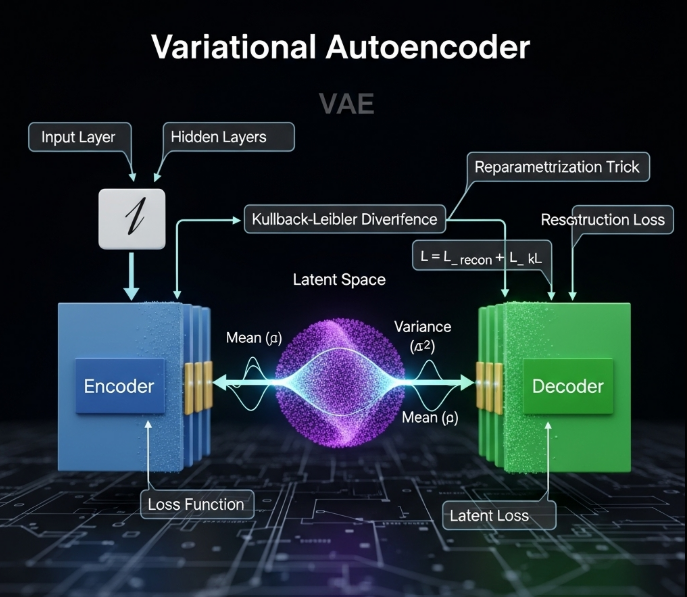

In [6]:
#!/usr/bin/env python3
"""
vae_tour.py — A step‑by‑step Variational Autoencoder with playful visuals (PyTorch)
-------------------------------------------------------------------------------
What this script gives you (educational + hands‑on):

1) A clear, commented VAE implementation (encoder, decoder, reparameterization).
2) Visuals that make the concepts click:
   • Reconstruction grids (input vs. output)
   • 2D latent space scatter (MNIST / Fashion‑MNIST)
   • Latent grid sampling (decode a meshgrid in z)
   • Interpolations between two images
   • (Creative!) If you pass a video (e.g., your Google Veo 8s clip), the script
     extracts frames, trains a tiny VAE on them (demo-level), and plots the
     latent trajectory over time — plus a reconstructed video.
3) Beta‑VAE and KL warmup so you can *feel* the ELBO pieces shaping the space.

Quick start
-----------
# Install dependencies (PyTorch CPU shown; feel free to install CUDA build):
python -m pip install torch torchvision matplotlib opencv-python imageio

# Train on MNIST with a 2D latent for easy visualization
python vae_tour.py --dataset mnist --epochs 10 --latent-dim 2

# Train on your video (demo; low data). This will sample ~2 frames/sec.
python vae_tour.py --dataset video --video-path ./my_veo_clip.mp4 --epochs 30 --latent-dim 2 --sample-fps 2

# Use Fashion‑MNIST instead of MNIST
python vae_tour.py --dataset fashion --epochs 15 --latent-dim 2 --beta 2.0 --kl-warmup-epochs 5

All outputs go to a timestamped folder under ./outputs/... :
  - reconstructions.png              (before/after grid)
  - latent_scatter.png               (2D scatter for labeled datasets)
  - latent_grid.png                  (decoded meshgrid)
  - interpolation.png                (z‑space walk between two images)
  - train_curves.png                 (loss, recon, KL by epoch)
  - video_latent_path.png            (video mode: time path through latent)
  - video_reconstruction.mp4 (or .gif if mp4 fails) (video mode)
  - checkpoint.pt                    (VAE weights + config)

Notes
-----
• For *understanding*, set --latent-dim 2 so you can see the space.
• Video mode is for intuition: tiny dataset → overfit risk → still great for
  seeing a smooth path in latent space.
• You can skip training with --no-train if you already have checkpoint.pt.

MIT License — do whatever you want; attribution appreciated. :)
"""
from __future__ import annotations
import argparse
import dataclasses as dc
import math
import os
import random
import sys
import time
from datetime import datetime
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Optional imports guarded for environments without video libs
try:
    import cv2
except Exception:
    cv2 = None

try:
    import imageio
except Exception:
    imageio = None

import matplotlib
matplotlib.use("Agg")  # headless
import matplotlib.pyplot as plt

try:
    from torchvision import datasets, transforms, utils as tvutils
except Exception as e:
    datasets = None
    transforms = None
    tvutils = None

# -------------------------------
# Utilities & configuration
# -------------------------------


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def pick_device(arg_device: str = "auto") -> torch.device:
    if arg_device != "auto":
        return torch.device(arg_device)
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Apple M‑series
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dc.dataclass
class RunConfig:
    dataset: str = "mnist"  # mnist | fashion | video
    video_path: Optional[str] = None
    sample_fps: float = 2.0
    epochs: int = 10
    batch_size: int = 128
    lr: float = 1e-3
    beta: float = 1.0           # weight on KL term (β‑VAE)
    kl_warmup_epochs: int = 0   # linearly ramp β from 0→beta
    latent_dim: int = 2
    output_dir: str = "outputs"
    seed: int = 42
    device: str = "auto"
    no_train: bool = False
    checkpoint: Optional[str] = None


# -------------------------------
# Data
# -------------------------------

class FramesDataset(Dataset):
    """Wraps a list/array of frames (H, W) or (H, W, 3) in [0,1] floats."""
    def __init__(self, frames: np.ndarray):
        assert frames.ndim in (3, 4)
        # ensure (N, 1, H, W), grayscale
        if frames.ndim == 4 and frames.shape[-1] == 3:
            frames = np.mean(frames, axis=-1, keepdims=True)  # to gray
        elif frames.ndim == 3:
            frames = frames[..., None]
        frames = frames.astype(np.float32)
        frames = np.transpose(frames, (0, 3, 1, 2))  # NCHW
        self.frames = frames

    def __len__(self):
        return self.frames.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.frames[idx])
        return x, -1  # label unknown


def extract_video_frames(path: str, sample_fps: float = 2.0, out_size: Tuple[int, int] = (28, 28)) -> np.ndarray:
    if cv2 is None:
        raise RuntimeError("OpenCV (cv2) is not installed. Install with: pip install opencv-python")
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step = max(1, int(round(fps / sample_fps)))

    frames = []
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            # to gray, resize, normalize 0..1
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, out_size, interpolation=cv2.INTER_AREA)
            gray = gray.astype(np.float32) / 255.0
            frames.append(gray)
        idx += 1
    cap.release()

    if len(frames) == 0:
        raise RuntimeError("No frames extracted. Try a different --sample-fps or confirm the video file.")

    return np.stack(frames, axis=0)  # (N, H, W)


# -------------------------------
# Model: Conv VAE for 28×28 grayscale
# -------------------------------

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),  # 28→14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # 14→7
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(64 * 7 * 7, 256)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = torch.flatten(h, 1)
        h = F.relu(self.fc(h))
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 64 * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 7→14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),   # 14→28
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 64, 7, 7)
        xhat = self.deconv(h)
        return xhat


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        xhat = self.decoder(z)
        return xhat, mu, logvar, z


# -------------------------------
# Loss (ELBO pieces)
# -------------------------------

def elbo_loss(x, xhat, mu, logvar, beta=1.0):
    # Reconstruction: binary cross‑entropy over pixels
    bce = F.binary_cross_entropy(xhat, x, reduction='sum') / x.shape[0]
    # KL divergence to N(0,I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return bce + beta * kl, bce.detach(), kl.detach()


# -------------------------------
# Training & evaluation helpers
# -------------------------------

def save_image_grid(tensor, path, nrow=8, title: Optional[str] = None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    grid = tvutils.make_grid(tensor.cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(8, 8))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def plot_latent_scatter(zs, ys, path, title="Latent space (2D)"):
    plt.figure(figsize=(6, 5))
    if ys is not None and (ys >= 0).any():
        scatter = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap='tab10', s=10, alpha=0.8)
        cbar = plt.colorbar(scatter)
        cbar.set_label('label')
    else:
        plt.scatter(zs[:, 0], zs[:, 1], s=10, alpha=0.8)
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def plot_latent_grid(decoder: Decoder, path: str, grid_lim=3.0, steps=20, device=None):
    # Decode a meshgrid in latent space to see structure
    lin = np.linspace(-grid_lim, grid_lim, steps)
    zgrid = np.stack(np.meshgrid(lin, lin), axis=-1).reshape(-1, 2)
    z = torch.tensor(zgrid, dtype=torch.float32, device=device)
    with torch.no_grad():
        xh = decoder(z)
    xh = xh.view(steps * steps, 1, 28, 28)

    # Stitch into an image manually to have row/col order visible
    canvas = torch.zeros(1, steps * 28, steps * 28)
    k = 0
    for i in range(steps):
        for j in range(steps):
            canvas[:, i*28:(i+1)*28, j*28:(j+1)*28] = xh[k]
            k += 1
    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.imshow(canvas.squeeze(0).cpu(), cmap='gray')
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()


def interpolate_pair(model: VAE, x1, x2, steps=10, device=None):
    model.eval()
    with torch.no_grad():
        mu1, logvar1 = model.encoder(x1)
        mu2, logvar2 = model.encoder(x2)
        z1 = mu1  # use mean for a smooth path
        z2 = mu2
        alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
        zs = (1 - alphas) * z1 + alphas * z2
        xhs = model.decoder(zs)
    return xhs


def train_epoch(model, loader, opt, epoch, cfg: RunConfig):
    model.train()
    running = {'loss': 0.0, 'bce': 0.0, 'kl': 0.0}
    beta = cfg.beta
    if cfg.kl_warmup_epochs > 0 and epoch < cfg.kl_warmup_epochs:
        beta = cfg.beta * (epoch + 1) / cfg.kl_warmup_epochs
    for x, _ in loader:
        x = x.to(device)
        opt.zero_grad()
        xhat, mu, logvar, _ = model(x)
        loss, bce, kl = elbo_loss(x, xhat, mu, logvar, beta=beta)
        loss.backward()
        opt.step()
        running['loss'] += loss.item() * x.size(0)
        running['bce'] += bce.item() * x.size(0)
        running['kl'] += kl.item() * x.size(0)
    n = len(loader.dataset)
    return {k: v / n for k, v in running.items()}, beta


def eval_epoch(model, loader, cfg: RunConfig):
    model.eval()
    running = {'loss': 0.0, 'bce': 0.0, 'kl': 0.0}
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            xhat, mu, logvar, _ = model(x)
            loss, bce, kl = elbo_loss(x, xhat, mu, logvar, beta=cfg.beta)
            running['loss'] += loss.item() * x.size(0)
            running['bce'] += bce.item() * x.size(0)
            running['kl'] += kl.item() * x.size(0)
    n = len(loader.dataset)
    return {k: v / n for k, v in running.items()}


# -------------------------------
# Main
# -------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="A step‑by‑step VAE with visuals")
    parser.add_argument('--dataset', choices=['mnist', 'fashion', 'video'], default='mnist')
    parser.add_argument('--video-path', type=str, default=None)
    parser.add_argument('--sample-fps', type=float, default=2.0)
    parser.add_argument('--epochs', type=int, default=10)
    parser.add_argument('--batch-size', type=int, default=128)
    parser.add_argument('--lr', type=float, default=1e-3)
    parser.add_argument('--beta', type=float, default=1.0)
    parser.add_argument('--kl-warmup-epochs', type=int, default=0)
    parser.add_argument('--latent-dim', type=int, default=2)
    parser.add_argument('--output-dir', type=str, default='outputs')
    parser.add_argument('--seed', type=int, default=42)
    parser.add_argument('--device', type=str, default='auto', help='auto|cpu|cuda|mps')
    parser.add_argument('--no-train', action='store_true', help='skip training and only run visualizations if checkpoint is available')
    parser.add_argument('--checkpoint', type=str, default=None, help='path to load/save checkpoint (defaults to outputs/.../checkpoint.pt)')
    args, _ = parser.parse_known_args()  # tolerate Jupyter/Colab extra args like -f <kernel.json>

    cfg = RunConfig(
        dataset=args.dataset,
        video_path=args.video_path,
        sample_fps=args.sample_fps,
        epochs=args.epochs,
        batch_size=args.batch_size,
        lr=args.lr,
        beta=args.beta,
        kl_warmup_epochs=args.kl_warmup_epochs,
        latent_dim=args.latent_dim,
        output_dir=args.output_dir,
        seed=args.seed,
        device=args.device,
        no_train=args.no_train,
        checkpoint=args.checkpoint,
    )

    seed_everything(cfg.seed)
    device = pick_device(cfg.device)
    print(f"Using device: {device}")

    # Timestamped run dir
    run_dir = os.path.join(cfg.output_dir, datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
    os.makedirs(run_dir, exist_ok=True)
    ckpt_path = cfg.checkpoint or os.path.join(run_dir, "checkpoint.pt")

    # Data
    if cfg.dataset in ("mnist", "fashion"):
        if datasets is None or transforms is None:
            raise RuntimeError("torchvision is required. Install with: pip install torchvision")
        tfm = transforms.Compose([
            transforms.ToTensor(),  # [0,1]
        ])
        if cfg.dataset == "mnist":
            train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
            test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
        else:
            train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
            test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)
    else:
        if not cfg.video_path:
            print("--video-path is required for dataset=video", file=sys.stderr)
            sys.exit(2)
        frames = extract_video_frames(cfg.video_path, cfg.sample_fps, out_size=(28, 28))
        # split 80/20
        n = len(frames)
        split = max(1, int(0.8 * n))
        train_frames = frames[:split]
        test_frames = frames[split:]
        train_ds = FramesDataset(train_frames)
        test_ds = FramesDataset(test_frames if len(test_frames) > 0 else train_frames)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

    # Model
    model = VAE(cfg.latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    # Train
    history = {"train": [], "val": [], "beta": []}
    if not cfg.no_train:
        best_val = float('inf')
        for epoch in range(cfg.epochs):
            tr_metrics, beta_used = train_epoch(model, train_loader, opt, epoch, cfg)
            val_metrics = eval_epoch(model, test_loader, cfg)
            history["train"].append(tr_metrics)
            history["val"].append(val_metrics)
            history["beta"].append(beta_used)

            print(f"Epoch {epoch+1:02d}/{cfg.epochs} | beta={beta_used:.3f} | "
                  f"train loss={tr_metrics['loss']:.2f} (rec={tr_metrics['bce']:.2f}, kl={tr_metrics['kl']:.2f}) | "
                  f"val loss={val_metrics['loss']:.2f}")

            if val_metrics['loss'] < best_val:
                best_val = val_metrics['loss']
                torch.save({
                    'config': dc.asdict(cfg),
                    'model_state': model.state_dict(),
                }, ckpt_path)
        print(f"Saved best checkpoint to {ckpt_path}")
    else:
        # Load existing
        if cfg.checkpoint and os.path.exists(cfg.checkpoint):
            ckpt = torch.load(cfg.checkpoint, map_location=device)
            model.load_state_dict(ckpt['model_state'])
            print(f"Loaded checkpoint from {cfg.checkpoint}")
        else:
            print("--no-train was set but no checkpoint was provided; continuing anyway.")

    # If we trained this run, ensure we have the final weights loaded (best)
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])

    # ------------------
    # Reconstructions
    # ------------------
    model.eval()
    with torch.no_grad():
        x, y = next(iter(test_loader))
        x = x.to(device)
        xhat, mu, logvar, z = model(x)
    # stack original & recon side-by-side
    k = min(8, x.size(0))
    pair = torch.cat([x[:k], xhat[:k]])
    save_image_grid(pair, os.path.join(run_dir, "reconstructions.png"), nrow=k,
                    title="Top: originals • Bottom: reconstructions")

    # ------------------
    # Latent scatter (2D)
    # ------------------
    if cfg.latent_dim == 2:
        zs = []
        ys = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                mu, logvar = model.encoder(xb)
                zs.append(mu.cpu().numpy())  # use means for a clean map
                ys.append(yb.numpy())
        zs = np.concatenate(zs, axis=0)
        ys = np.concatenate(ys, axis=0)
        if cfg.dataset == 'video':
            # color by (normalized) time index
            ys = np.arange(len(zs))
        plot_latent_scatter(zs, ys, os.path.join(run_dir, "latent_scatter.png"),
                            title="Latent space (2D)")

        # Also decode a meshgrid to see what images live where
        plot_latent_grid(model.decoder, os.path.join(run_dir, "latent_grid.png"), device=device)

    # ------------------
    # Interpolation
    # ------------------
    if len(test_ds) >= 2:
        x1 = test_ds[0][0].unsqueeze(0).to(device)
        x2 = test_ds[1][0].unsqueeze(0).to(device)
        interp = interpolate_pair(model, x1, x2, steps=12, device=device)
        save_image_grid(interp, os.path.join(run_dir, "interpolation.png"), nrow=12,
                        title="Latent interpolation (decode of α·z1 + (1-α)·z2)")

    # ------------------
    # Training curves
    # ------------------
    if len(history["train"]) > 0:
        tr_loss = [d['loss'] for d in history['train']]
        tr_bce  = [d['bce']  for d in history['train']]
        tr_kl   = [d['kl']   for d in history['train']]
        va_loss = [d['loss'] for d in history['val']]
        xs = np.arange(1, len(tr_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(xs, tr_loss, label='train total')
        plt.plot(xs, va_loss, label='val total')
        plt.plot(xs, tr_bce, label='train recon')
        plt.plot(xs, tr_kl, label='train KL')
        if any(history['beta']):
            plt.twinx()
            plt.plot(xs, history['beta'], label='beta', linestyle='--')
        plt.xlabel('epoch')
        plt.title('Training curves (lower is better)')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.savefig(os.path.join(run_dir, 'train_curves.png'), dpi=200)
        plt.close()

    # ------------------
    # Video‑specific extras
    # ------------------
    if cfg.dataset == 'video' and cfg.latent_dim == 2:
        # Path through latent space over time
        with torch.no_grad():
            zs = []
            for xb, _ in DataLoader(test_ds, batch_size=1, shuffle=False):
                mu, logvar = model.encoder(xb.to(device))
                zs.append(mu.squeeze(0).cpu().numpy())
            zs = np.stack(zs, axis=0)
        plt.figure(figsize=(3, 2))
        plt.plot(zs[:, 0], zs[:, 1], marker='o', markersize=3)
        for i in range(0, len(zs), max(1, len(zs)//10)):
            plt.text(zs[i, 0], zs[i, 1], str(i), fontsize=8)
        plt.xlabel('z1')
        plt.ylabel('z2')
        plt.title('Video latent trajectory (time →)')
        plt.tight_layout()
        plt.savefig(os.path.join(run_dir, 'video_latent_path.png'), dpi=200)
        plt.close()

        # Reconstructed video from test split
        if imageio is not None:
            # Decode means for each frame for stability
            recons = []
            with torch.no_grad():
                for xb, _ in DataLoader(test_ds, batch_size=1, shuffle=False):
                    mu, _ = model.encoder(xb.to(device))
                    xh = model.decoder(mu)
                    img = (xh.squeeze(0).squeeze(0).cpu().numpy() * 255).astype(np.uint8)
                    recons.append(img)
            # Try MP4 first via cv2; fallback to GIF
            mp4_path = os.path.join(run_dir, 'video_reconstruction.mp4')
            gif_path = os.path.join(run_dir, 'video_reconstruction.gif')
            saved = False
            if cv2 is not None:
                try:
                    h, w = recons[0].shape
                    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
                    vw = cv2.VideoWriter(mp4_path, fourcc, cfg.sample_fps, (w, h), isColor=False)
                    for frame in recons:
                        vw.write(cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR))
                    vw.release()
                    if os.path.exists(mp4_path) and os.path.getsize(mp4_path) > 0:
                        saved = True
                except Exception:
                    saved = False
            if not saved:
                try:
                    imageio.mimsave(gif_path, recons, duration=1.0 / max(1, cfg.sample_fps))
                    saved = True
                except Exception:
                    saved = False
            print("Saved reconstructed video to:", mp4_path if saved and os.path.exists(mp4_path) else gif_path)

    # ------------------
    # Final friendly summary
    # ------------------
    print("\nDone! Key artifacts in:", run_dir)
    print("- reconstructions.png  → input vs output\n- latent_scatter.png   → where inputs land in z\n- latent_grid.png      → what the decoder thinks lives in each region\n- interpolation.png    → walk between two examples\n- train_curves.png     → ELBO pieces over time\n- (video mode) video_latent_path.png + video_reconstruction.mp4/.gif")


Using device: cpu
Epoch 01/10 | beta=1.000 | train loss=184.22 (rec=179.79, kl=4.43) | val loss=162.42
Epoch 02/10 | beta=1.000 | train loss=158.73 (rec=153.44, kl=5.29) | val loss=155.86
Epoch 03/10 | beta=1.000 | train loss=154.27 (rec=148.62, kl=5.64) | val loss=152.72
Epoch 04/10 | beta=1.000 | train loss=151.76 (rec=145.92, kl=5.84) | val loss=151.49
Epoch 05/10 | beta=1.000 | train loss=150.11 (rec=144.13, kl=5.98) | val loss=149.44
Epoch 06/10 | beta=1.000 | train loss=148.83 (rec=142.74, kl=6.09) | val loss=148.69
Epoch 07/10 | beta=1.000 | train loss=147.69 (rec=141.49, kl=6.20) | val loss=147.66
Epoch 08/10 | beta=1.000 | train loss=146.78 (rec=140.52, kl=6.26) | val loss=147.16
Epoch 09/10 | beta=1.000 | train loss=145.97 (rec=139.64, kl=6.33) | val loss=146.49
Epoch 10/10 | beta=1.000 | train loss=145.28 (rec=138.88, kl=6.40) | val loss=145.76
Saved best checkpoint to outputs/2025-08-19_21-00-39/checkpoint.pt

Done! Key artifacts in: outputs/2025-08-19_21-00-39
- reconstruc

Using run_dir: outputs/2025-08-19_21-00-39
reconstructions.png


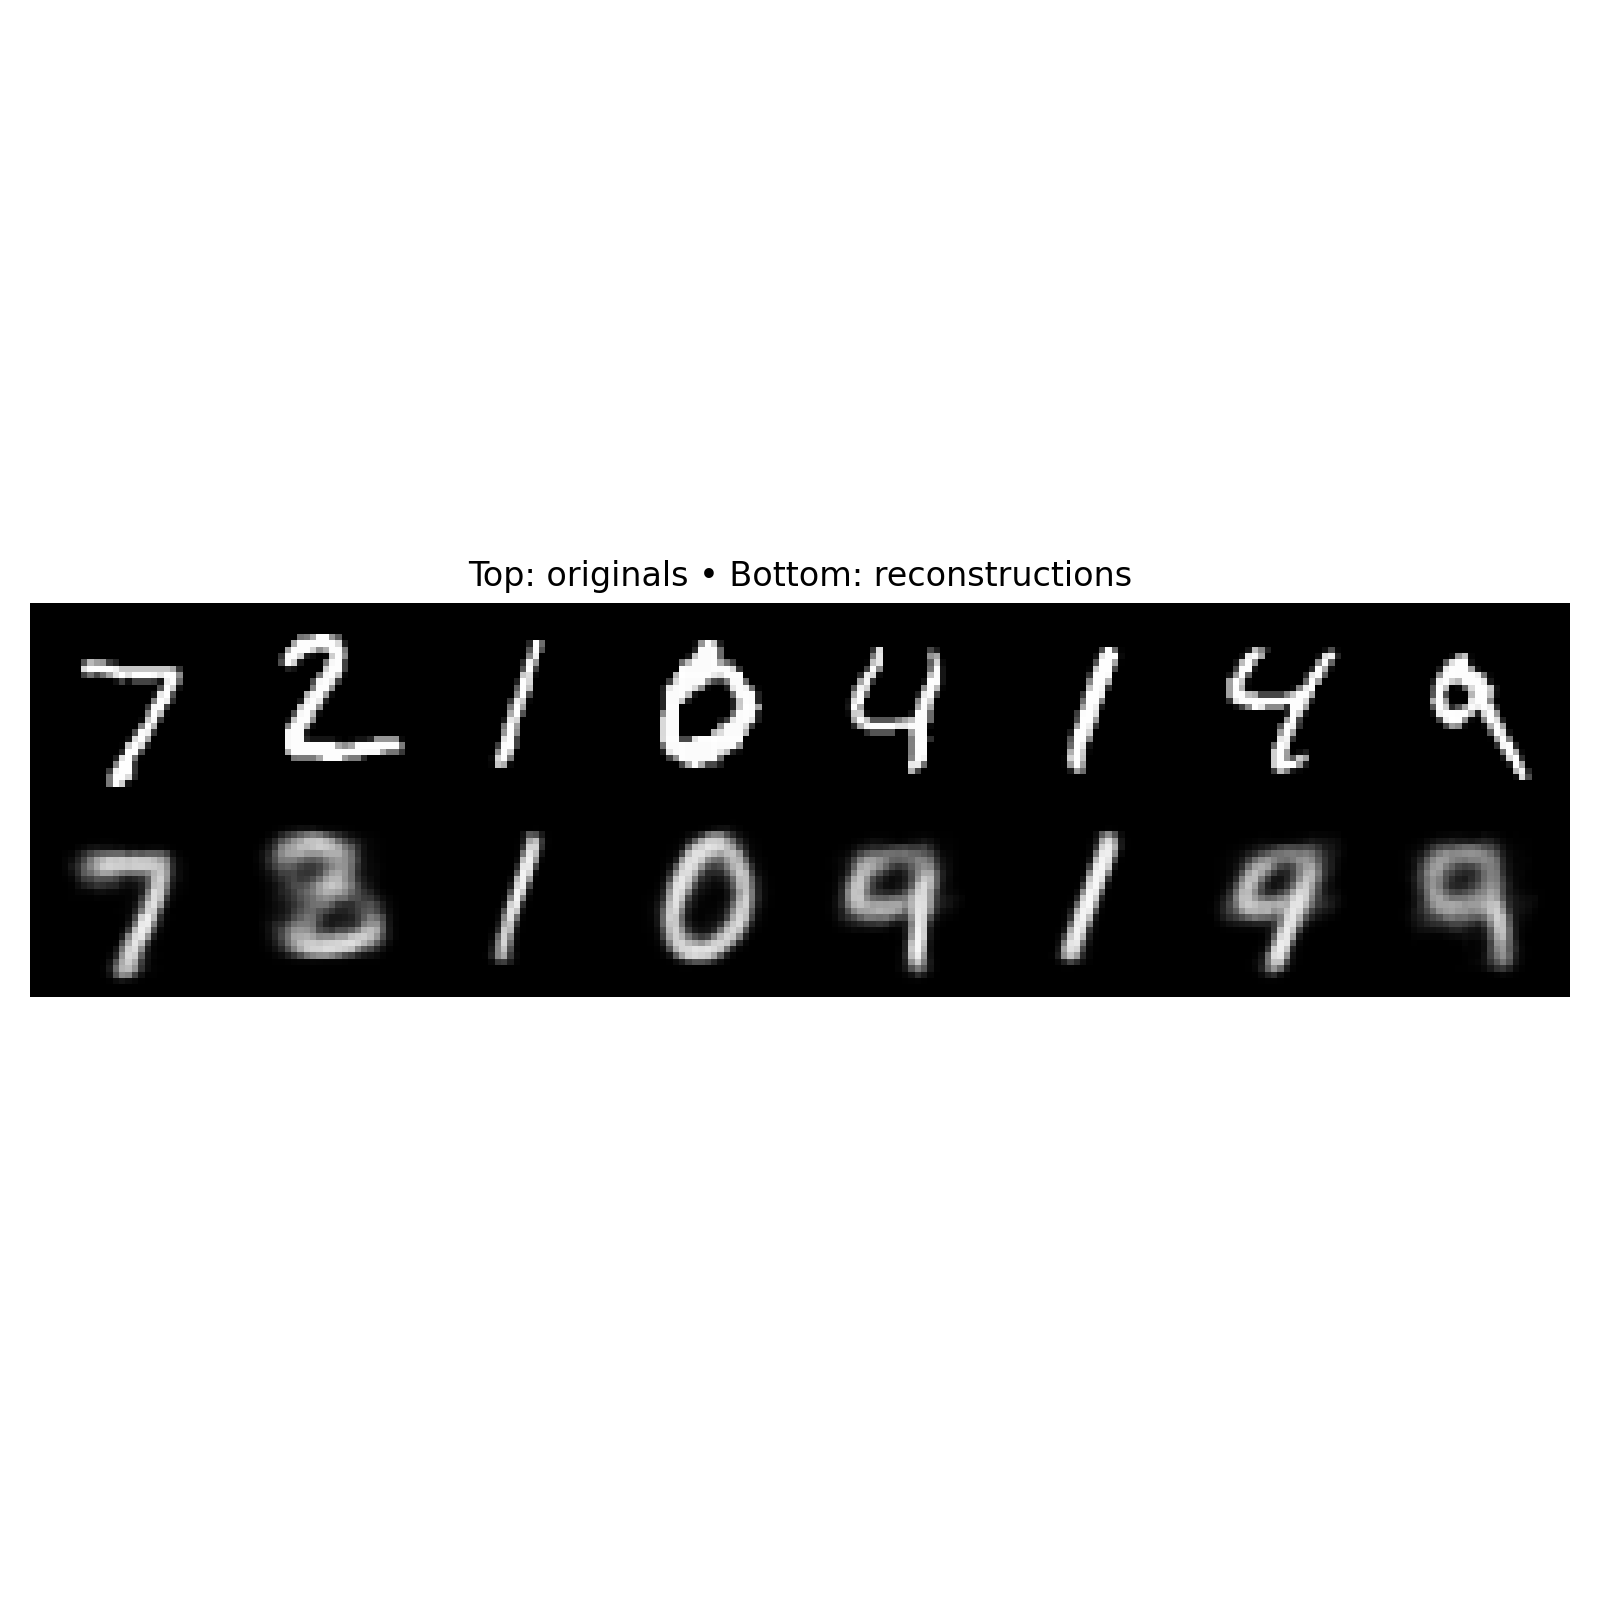

latent_scatter.png


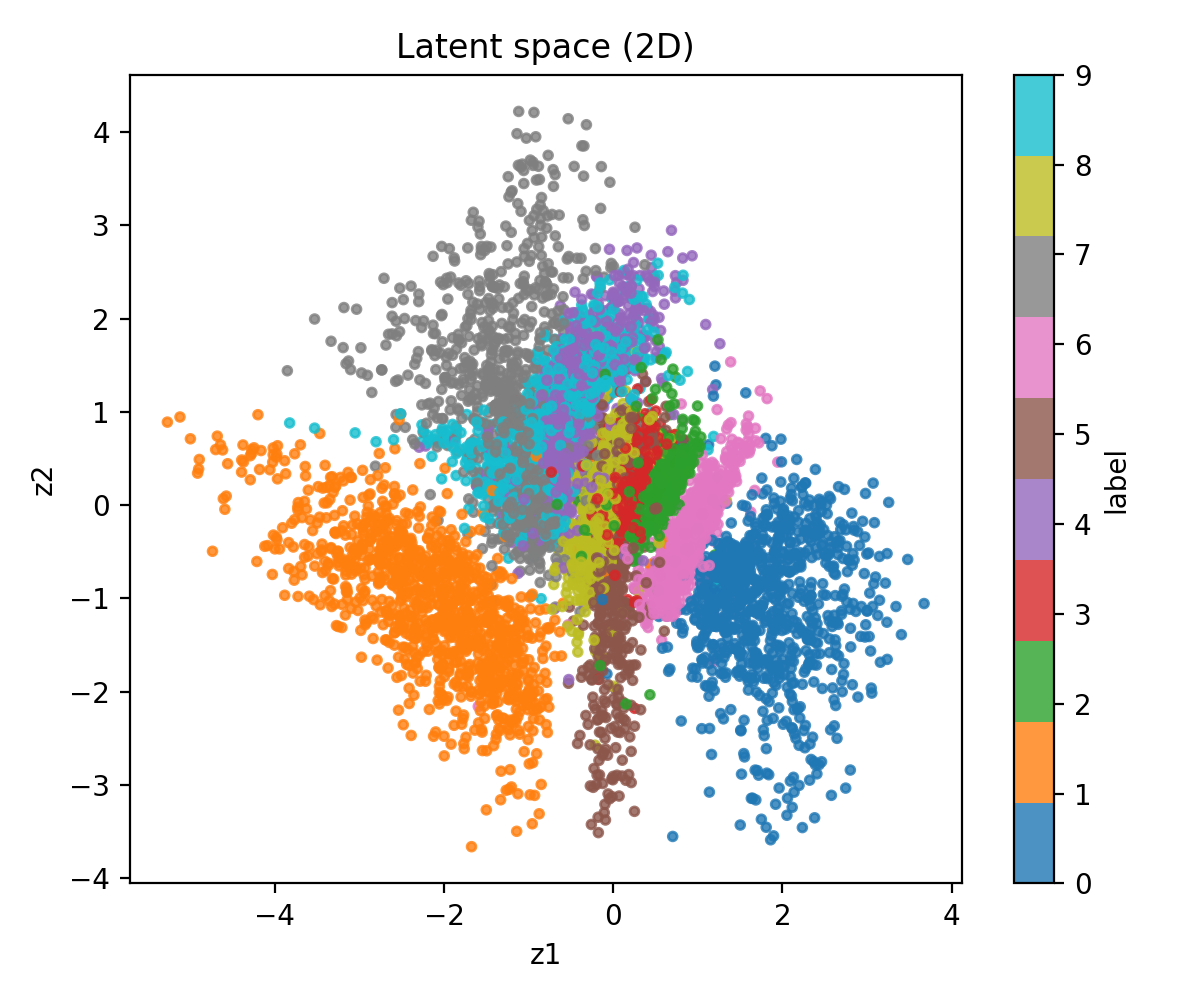

latent_grid.png


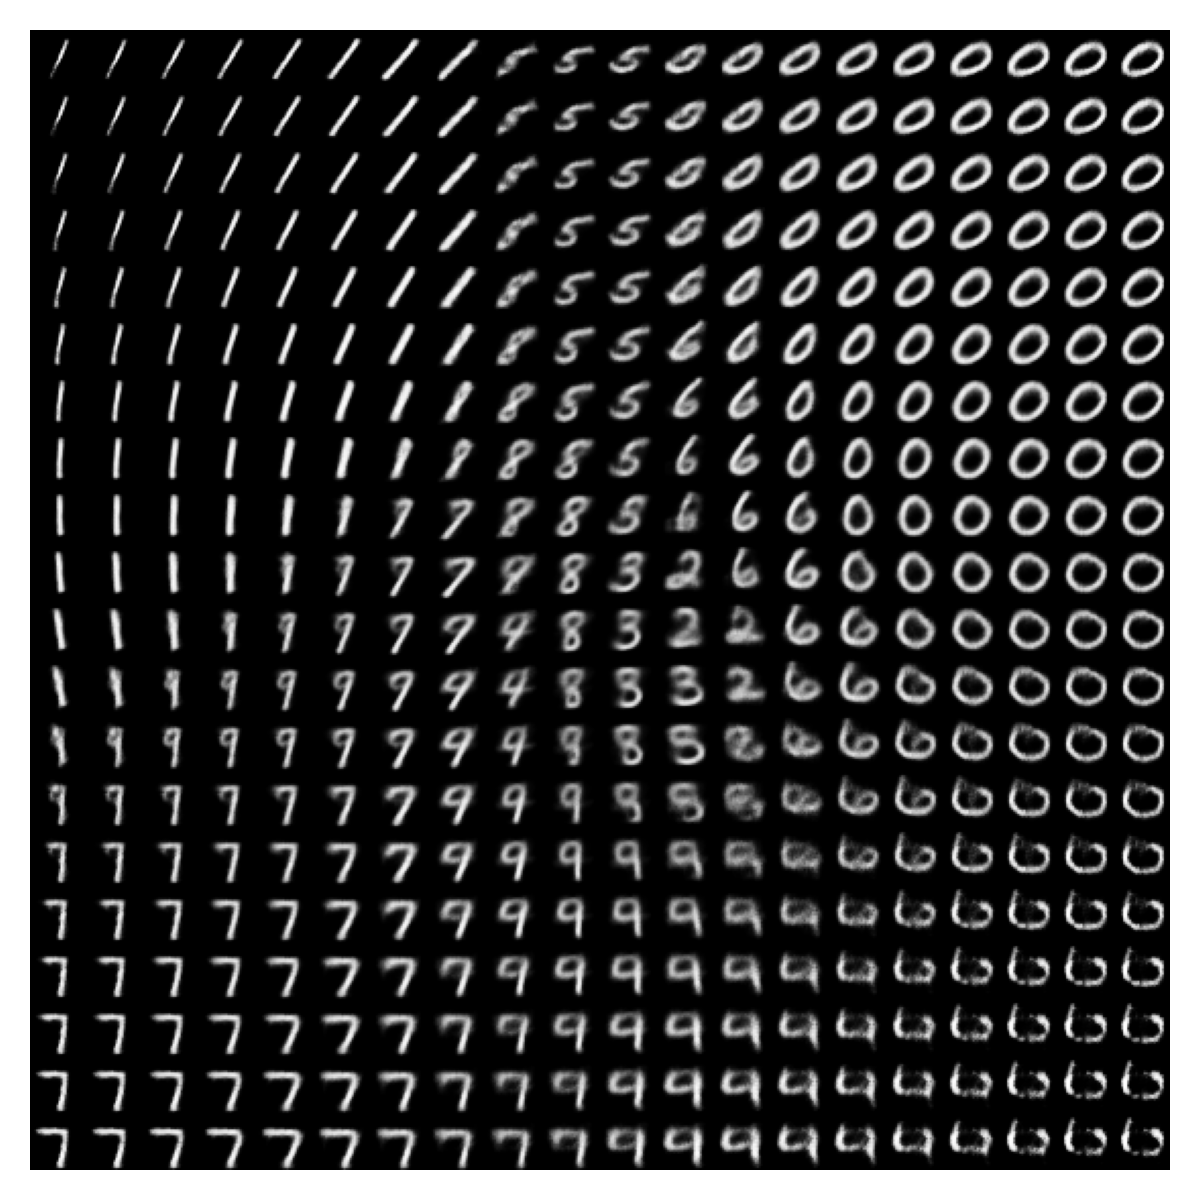

interpolation.png


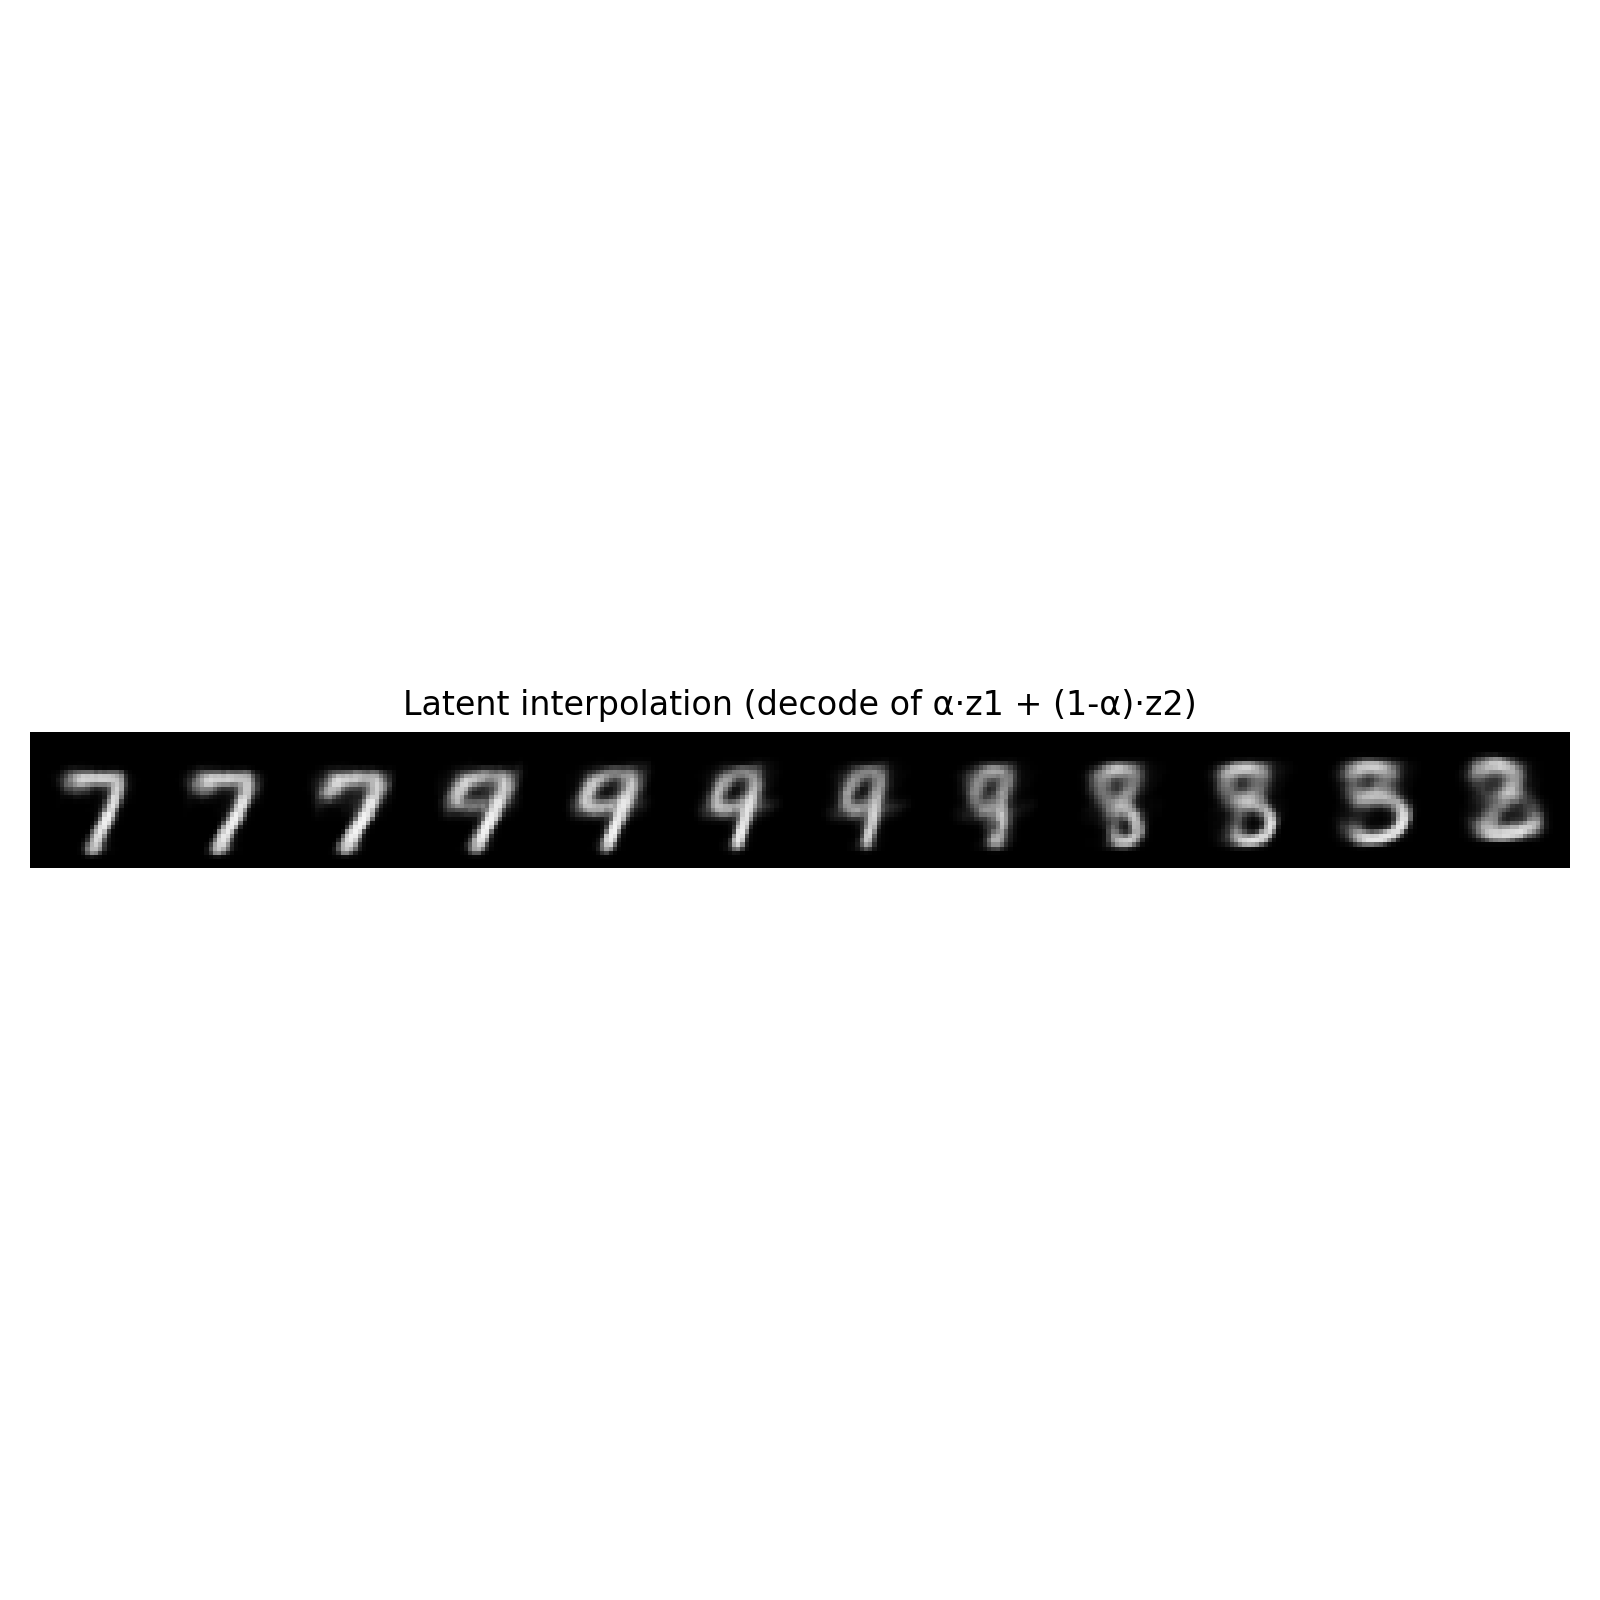

train_curves.png


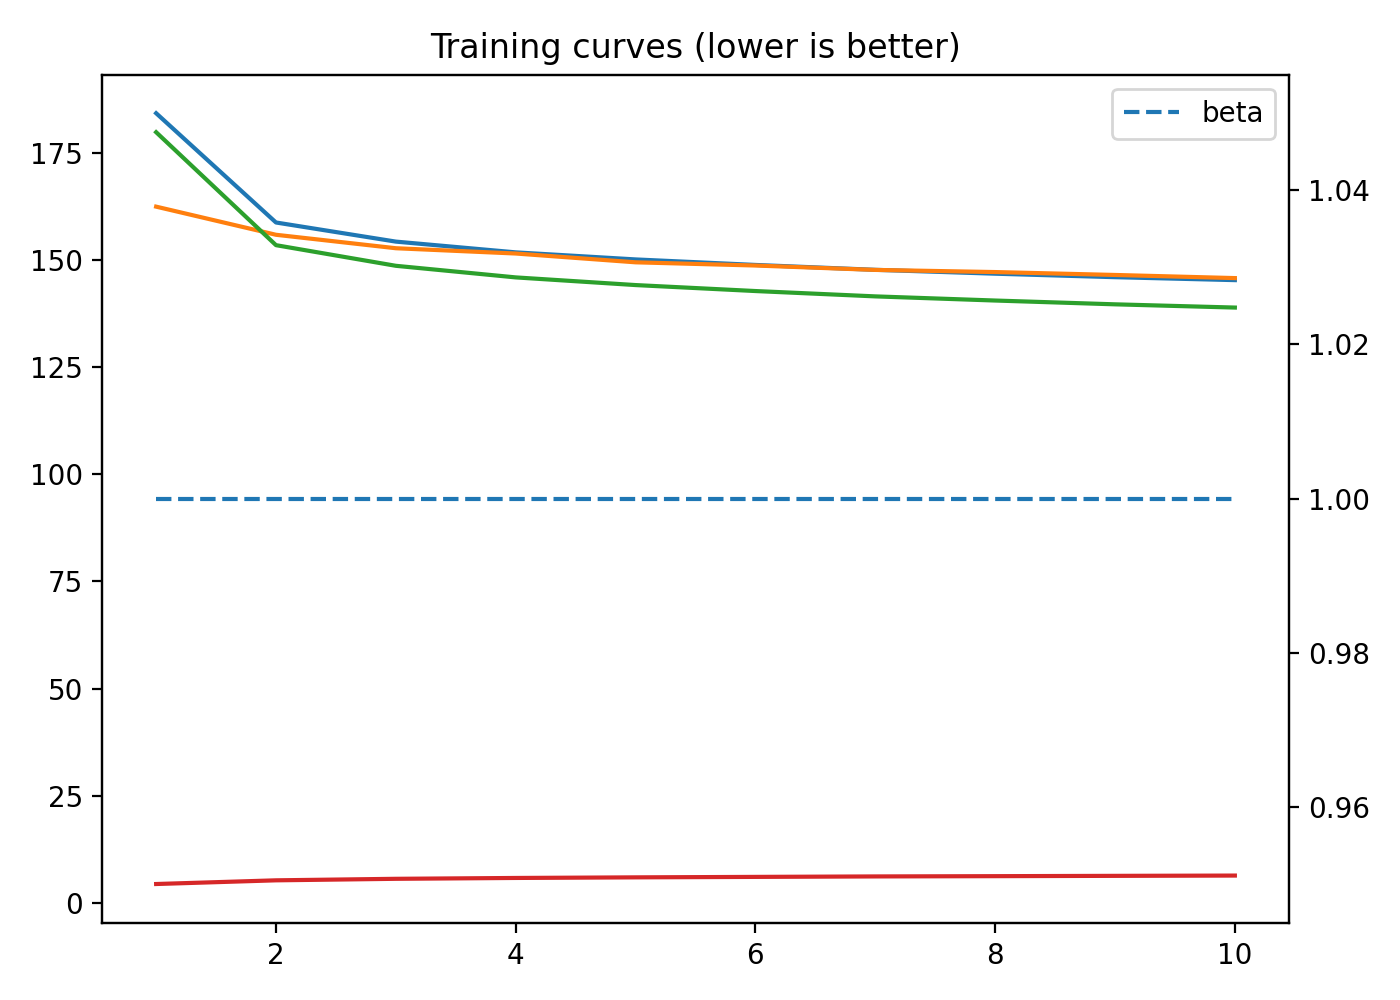

No reconstructed video found (only created in --dataset video).


In [8]:
# Find the latest output folder and preview all artifacts (smaller display)
import os, glob
from IPython.display import Image, display, Video

IMG_WIDTH = 400   # pixels; adjust to taste (e.g., 240, 320, 400)
VIDEO_WIDTH = 580 # pixels for inline video

# Pick the newest run folder under ./outputs
run_dir = sorted(glob.glob("outputs/*"), key=os.path.getmtime)[-1]
print("Using run_dir:", run_dir)

pics = [
    "reconstructions.png",
    "latent_scatter.png",
    "latent_grid.png",
    "interpolation.png",
    "train_curves.png",
    "video_latent_path.png",   # will exist only for --dataset video
]

for p in pics:
    path = os.path.join(run_dir, p)
    if os.path.exists(path):
        print(p)
        display(Image(filename=path, width=IMG_WIDTH))  # scaled down

# If you trained on a video, show the reconstructed clip (mp4 or gif)
mp4 = os.path.join(run_dir, "video_reconstruction.mp4")
gif = os.path.join(run_dir, "video_reconstruction.gif")

if os.path.exists(mp4):
    print("video_reconstruction.mp4")
    display(Video(mp4, embed=True, width=VIDEO_WIDTH))   # scaled down
elif os.path.exists(gif):
    print("video_reconstruction.gif")
    display(Video(gif, embed=True, width=VIDEO_WIDTH))   # Colab can inline GIF too
else:
    print("No reconstructed video found (only created in --dataset video).")

# Generative AI Models — Technical

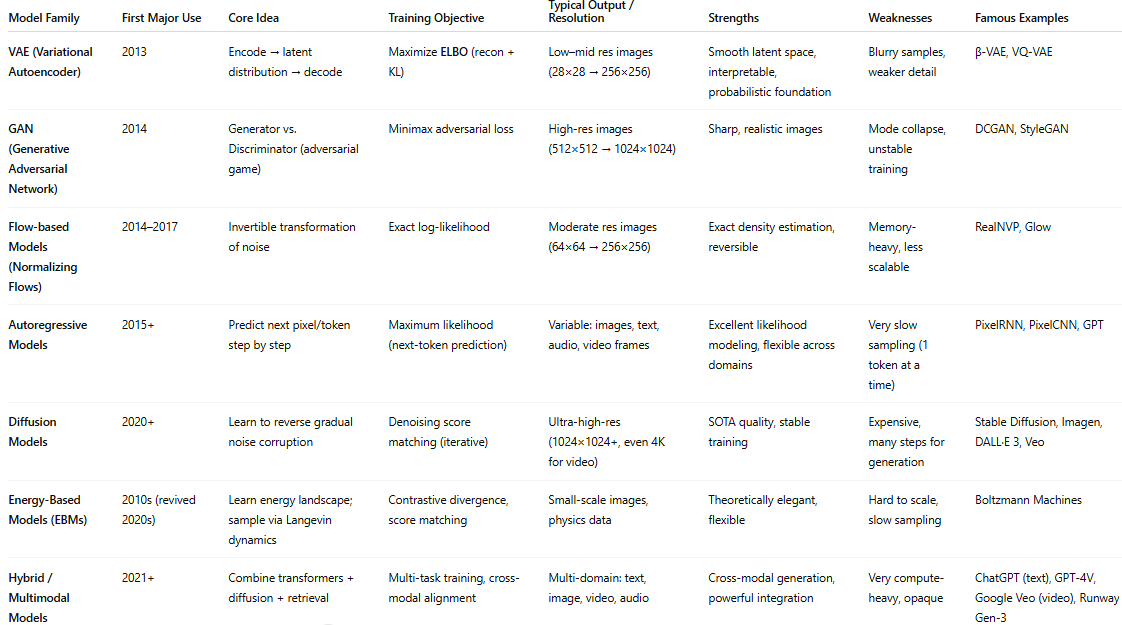

In [19]:
# --- Fix: use FigureWidget + enable widget manager in Colab ---
!pip -q install ipywidgets plotly==5.22.0
from google.colab import output
output.enable_custom_widget_manager()

import os, glob, io, base64, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as W
from IPython.display import display
from PIL import Image

# ---------- Minimal VAE to load your checkpoint ----------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(inplace=True),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(64*7*7, 256)
        self.mu, self.logvar = nn.Linear(256, latent_dim), nn.Linear(256, latent_dim)
    def forward(self, x):
        h = self.conv(x); h = torch.flatten(h,1); h = F.relu(self.fc(h))
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim,256), nn.ReLU(inplace=True),
                                nn.Linear(256,64*7*7), nn.ReLU(inplace=True))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,1,4,2,1), nn.Sigmoid())
    def forward(self, z):
        h = self.fc(z).view(-1,64,7,7); return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, latent_dim): super().__init__(); self.encoder=Encoder(latent_dim); self.decoder=Decoder(latent_dim)

# ---------- Load latest checkpoint ----------
run_dir = sorted(glob.glob("outputs/*"), key=os.path.getmtime)[-1]
ckpt = torch.load(os.path.join(run_dir,"checkpoint.pt"), map_location="cpu")
latent_dim = ckpt["config"]["latent_dim"]
dataset_name = ckpt["config"]["dataset"]

model = VAE(latent_dim); model.load_state_dict(ckpt["model_state"]); model.eval()

# ---------- Build dataset to encode ----------
tfm = transforms.Compose([transforms.ToTensor()])
if dataset_name in ("mnist","fashion"):
    ds_cls = datasets.MNIST if dataset_name=="mnist" else datasets.FashionMNIST
    ds = ds_cls("./data", train=False, download=True, transform=tfm)
    X = torch.stack([ds[i][0] for i in range(len(ds))], dim=0)  # (N,1,28,28)
else:
    import cv2
    def frames(path, fps=2.0, size=(28,28)):
        cap = cv2.VideoCapture(path); base = cap.get(cv2.CAP_PROP_FPS) or 30; step=max(1,int(round(base/fps)))
        arr=[]; i=0
        while True:
            ok, frm=cap.read();
            if not ok: break
            if i%step==0:
                g=cv2.cvtColor(frm,cv2.COLOR_BGR2GRAY); g=cv2.resize(g,size,interpolation=cv2.INTER_AREA)
                arr.append(g.astype(np.float32)/255.0)
            i+=1
        cap.release(); arr=np.stack(arr,0)
        return torch.from_numpy(arr[:,None,:,:])
    X = frames(ckpt["config"]["video_path"], ckpt["config"].get("sample_fps",2.0))

with torch.no_grad():
    mu,_ = model.encoder(X)
    Z = mu.cpu().numpy()
    XH = model.decoder(mu).cpu().numpy()
X = X.cpu().numpy()

def png_b64(a):
    im = Image.fromarray((a*255).astype("uint8"), mode="L").resize((96,96), Image.NEAREST)
    buf = io.BytesIO(); im.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

thumb_o = np.array([png_b64(X[i,0]) for i in range(len(X))], dtype=object)
thumb_r = np.array([png_b64(XH[i,0]) for i in range(len(XH))], dtype=object)

# ---------- FigureWidget instead of plain Figure ----------
base = px.scatter(
    x=Z[:,0], y=Z[:,1],
    labels={"x":"z1","y":"z2"},
    title=f"Interactive latent space — {dataset_name}",
    height=600
)
base.update_traces(mode="markers", marker=dict(size=6, opacity=0.85))
base.update_layout(dragmode="lasso", margin=dict(r=260))

fig = go.FigureWidget(base)   # <<< KEY FIX

# selection ring
fig.add_scatter(x=[], y=[], mode="markers",
                marker=dict(size=14, symbol="circle-open", line=dict(width=2, color="red")),
                hoverinfo="skip")

# thumbnails at right
fig.add_layout_image(dict(xref="paper", yref="paper", x=1.14, y=0.96, sizex=0.20, sizey=0.20,
                          xanchor="left", yanchor="top", source=thumb_o[0]))
fig.add_layout_image(dict(xref="paper", yref="paper", x=1.14, y=0.70, sizex=0.20, sizey=0.20,
                          xanchor="left", yanchor="top", source=thumb_r[0]))
fig.add_annotation(xref="paper", yref="paper", x=1.14, y=0.99, text="Original", showarrow=False)
fig.add_annotation(xref="paper", yref="paper", x=1.14, y=0.73, text="Reconstruction", showarrow=False)

slider = W.IntSlider(value=0, min=0, max=len(Z)-1, step=1, description="index", continuous_update=False)
label_html = W.HTML()

def set_index(i:int):
    with fig.batch_update():
        fig.data[1].x = [Z[i,0]]
        fig.data[1].y = [Z[i,1]]
        fig.layout.images[0].source = thumb_o[i]
        fig.layout.images[1].source = thumb_r[i]
    label_html.value = f"<b>Index:</b> {i}"

def on_slide(ch):
    if ch["name"]=="value": set_index(int(ch["new"]))
slider.observe(on_slide, names="value")

def on_click(trace, points, selector):
    if points.point_inds: slider.value = int(points.point_inds[0])
fig.data[0].on_click(on_click)

# lasso/box -> grid preview
grid_out = W.Output()
def show_grid(indices, cols=8):
    with grid_out:
        grid_out.clear_output(wait=True)
        if not indices:
            display(W.HTML("<i>No points selected.</i>")); return
        rows=[]
        for r in range(0, len(indices), cols):
            cells=[f'<td style="padding:2px;"><img src="{thumb_o[i]}" width="64"><br><img src="{thumb_r[i]}" width="64"></td>'
                   for i in indices[r:r+cols]]
            rows.append("<tr>"+ "".join(cells) +"</tr>")
        html=f"""
        <div>
          <b>Selection:</b> {len(indices)} samples
          <table style="border-collapse:collapse;">{''.join(rows)}</table>
          <div style="font-size:12px;color:#555;">(Top: Original • Bottom: Reconstruction)</div>
        </div>
        """
        display(W.HTML(html))

def on_select(trace, points, selector):
    show_grid(points.point_inds)
fig.data[0].on_selection(on_select)

set_index(0)
display(W.VBox([fig, W.HBox([slider, label_html]), grid_out]))

/tmp/ipython-input-4154439810.py:79: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



    'data': [{'hovertemplate': 'z1=%{x}<br>z2=%{y}<extra></extra>',
            …

ModuleNotFoundError: No module named 'plotly.validators.layout.title._subtitle'

In [22]:
# ==== VAE Latent Explorer — Single Colab Cell ====
# - Installs/activates widgets
# - Loads latest ./outputs/*/checkpoint.pt
# - Computes latents & reconstructions
# - Interactive Plotly FigureWidget: click, slider, lasso→grid

# 0) Environment setup (widget-safe & template-safe)
!pip -q install "plotly==5.22.0" ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

import plotly.io as pio
pio.renderers.default = "colab"   # draw in cell
pio.templates.default = "none"    # avoid subtitle validator issues

# 1) Imports
import os, glob, io, base64, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
import plotly.graph_objects as go
import ipywidgets as W
from IPython.display import display
from PIL import Image

# 2) Minimal VAE (must match your training architecture)
class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(inplace=True),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(64*7*7, 256)
        self.mu, self.logvar = nn.Linear(256, latent_dim), nn.Linear(256, latent_dim)
    def forward(self, x):
        h = self.conv(x); h = torch.flatten(h,1); h = F.relu(self.fc(h))
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim,256), nn.ReLU(inplace=True),
            nn.Linear(256,64*7*7),     nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,1,4,2,1),  nn.Sigmoid(),
        )
    def forward(self, z):
        h = self.fc(z).view(-1,64,7,7); return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, latent_dim: int): super().__init__(); self.encoder=Encoder(latent_dim); self.decoder=Decoder(latent_dim)

# 3) Load latest checkpoint
run_dirs = sorted(glob.glob("outputs/*"), key=os.path.getmtime)
if not run_dirs:
    raise SystemExit("No outputs/* found. Train the VAE first.")
run_dir = run_dirs[-1]
ckpt_path = os.path.join(run_dir, "checkpoint.pt")
if not os.path.exists(ckpt_path):
    raise SystemExit(f"No checkpoint.pt in: {run_dir}")

ckpt = torch.load(ckpt_path, map_location="cpu")
cfg = ckpt["config"]
latent_dim = int(cfg["latent_dim"])
dataset_name = cfg["dataset"]

model = VAE(latent_dim)
model.load_state_dict(ckpt["model_state"])
model.eval()

# 4) Rebuild inputs to match training dataset
tfm = transforms.Compose([transforms.ToTensor()])

def load_video_frames(path, sample_fps=2.0, out_size=(28,28)):
    import cv2
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): raise FileNotFoundError(path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step = max(1, int(round(fps / sample_fps)))
    frames, i = [], 0
    while True:
        ok, frm = cap.read()
        if not ok: break
        if i % step == 0:
            g = cv2.cvtColor(frm, cv2.COLOR_BGR2GRAY)
            g = cv2.resize(g, out_size, interpolation=cv2.INTER_AREA)
            frames.append(g.astype(np.float32)/255.0)
        i += 1
    cap.release()
    if not frames: raise RuntimeError("No frames extracted.")
    arr = np.stack(frames, 0)                # (N,H,W)
    return torch.from_numpy(arr[:,None,:,:]) # (N,1,28,28)

if dataset_name in ("mnist","fashion"):
    ds_cls = datasets.MNIST if dataset_name=="mnist" else datasets.FashionMNIST
    ds = ds_cls("./data", train=False, download=True, transform=tfm)
    X = torch.stack([ds[i][0] for i in range(len(ds))], dim=0)  # (N,1,28,28)
    labels = np.array(ds.targets)
elif dataset_name == "video":
    video_path = cfg["video_path"]
    sample_fps = float(cfg.get("sample_fps", 2.0))
    X = load_video_frames(video_path, sample_fps=sample_fps)
    labels = np.arange(len(X))  # time index
else:
    raise SystemExit(f"Unknown dataset: {dataset_name}")

# 5) Encode all samples (μ for clean 2D map) and reconstruct
with torch.no_grad():
    mu, _ = model.encoder(X)
    Z  = mu.cpu().numpy()
    XH = model.decoder(mu).cpu().numpy()
X = X.cpu().numpy()

# 6) Thumbnails & helpers
def to_png_b64(arr):
    im = Image.fromarray((arr*255).astype("uint8"))
    if im.mode != "L": im = im.convert("L")
    im = im.resize((96,96), Image.NEAREST)
    buf = io.BytesIO(); im.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

thumb_o = np.array([to_png_b64(X[i,0])  for i in range(len(X))],  dtype=object)
thumb_r = np.array([to_png_b64(XH[i,0]) for i in range(len(XH))], dtype=object)

# 7) Interactive FigureWidget (click, slider, lasso→grid)
fig = go.FigureWidget()
fig.add_scattergl(
    x=Z[:,0], y=Z[:,1], mode="markers",
    marker=dict(size=6, opacity=0.9),
    customdata=np.arange(len(Z)).reshape(-1,1),
    hovertemplate="index=%{customdata[0]}<br>z1=%{x:.2f}, z2=%{y:.2f}<extra></extra>"
)
fig.add_scatter(  # selection ring
    x=[], y=[], mode="markers",
    marker=dict(size=14, symbol="circle-open", line=dict(width=2, color="red")),
    hoverinfo="skip"
)
fig.update_layout(
    xaxis_title="z1", yaxis_title="z2",
    width=900, height=600, margin=dict(r=260),
    dragmode="lasso"
)

# thumbnails on the right
fig.add_layout_image(dict(xref="paper", yref="paper", x=1.14, y=0.96, sizex=0.20, sizey=0.20,
                          xanchor="left", yanchor="top", source=thumb_o[0]))
fig.add_layout_image(dict(xref="paper", yref="paper", x=1.14, y=0.70, sizex=0.20, sizey=0.20,
                          xanchor="left", yanchor="top", source=thumb_r[0]))
fig.add_annotation(xref="paper", yref="paper", x=1.14, y=0.99, text="Original", showarrow=False)
fig.add_annotation(xref="paper", yref="paper", x=1.14, y=0.73, text="Reconstruction", showarrow=False)

# Controls & callbacks
slider = W.IntSlider(value=0, min=0, max=len(Z)-1, step=1, description="index", continuous_update=False)
label_html = W.HTML()

def set_index(i: int):
    with fig.batch_update():
        fig.data[1].x = [Z[i,0]]
        fig.data[1].y = [Z[i,1]]
        fig.layout.images[0].source = thumb_o[i]
        fig.layout.images[1].source = thumb_r[i]
    label_html.value = f"<b>Index:</b> {i}"

def on_slide(change):
    if change["name"] == "value": set_index(int(change["new"]))
slider.observe(on_slide, names="value")

def on_click(trace, points, selector):
    if points.point_inds: slider.value = int(points.point_inds[0])
fig.data[0].on_click(on_click)

grid_out = W.Output()
def show_grid(indices, cols=8):
    with grid_out:
        grid_out.clear_output(wait=True)
        if not indices:
            display(W.HTML("<i>No points selected.</i>")); return
        rows=[]
        for r in range(0, len(indices), cols):
            cells=[f'<td style="padding:2px;"><img src="{thumb_o[i]}" width="64"><br><img src="{thumb_r[i]}" width="64"></td>'
                   for i in indices[r:r+cols]]
            rows.append("<tr>" + "".join(cells) + "</tr>")
        html=f"""
        <div>
          <b>Selection:</b> {len(indices)} samples
          <table style="border-collapse:collapse;">{''.join(rows)}</table>
          <div style="font-size:12px;color:#555;">(Top: Original • Bottom: Reconstruction)</div>
        </div>
        """
        display(W.HTML(html))

def on_select(trace, points, selector):
    show_grid(points.point_inds)
fig.data[0].on_selection(on_select)

# 8) Display
set_index(0)
display(W.VBox([fig, W.HBox([slider, label_html]), grid_out]))


    'data': [{'customdata': array([[   0],
                                   [ …